ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

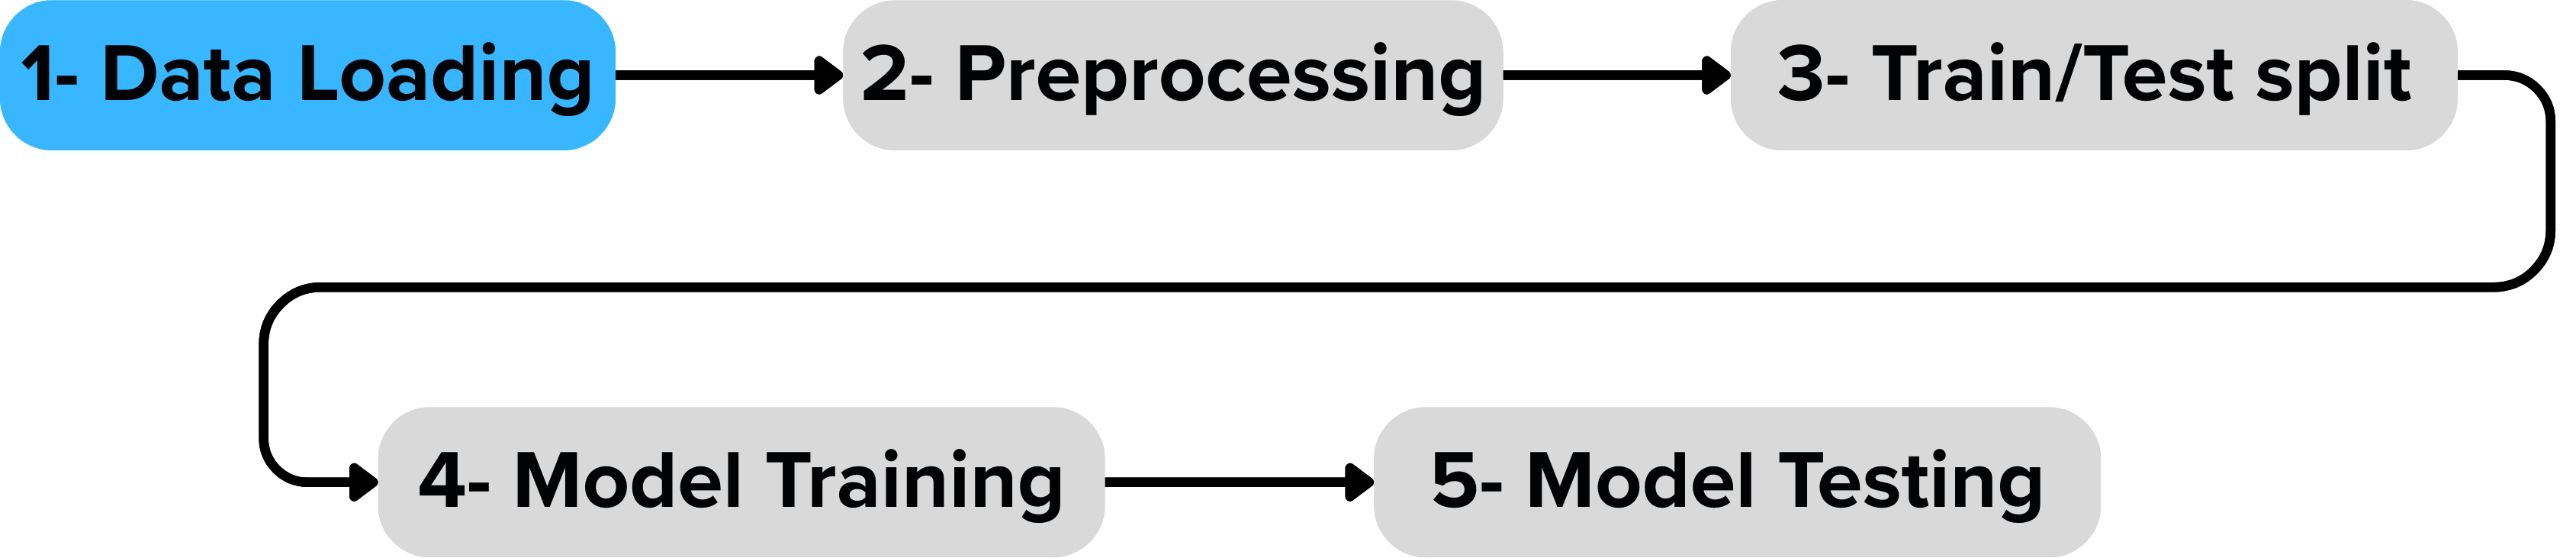

In [45]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

## Loading data in different ways
### Option 1: Load local CSV

In [43]:
# Load Dataset

df = pd.read_csv("data.csv", on_bad_lines='skip')
# Display first 5 rows
df.head(7)

,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1
5,AVYq1lDE4MgAZfNt,2
6,u6c8vhow,1


The dataset consists of individual chocolate sales records, where each row represents a single sales transaction.
The columns describe attributes such as the sales date, product information, sales location, and sales amount.
From the first few rows, we can observe that some columns contain textual data, while others contain numerical values stored as text, such as currency values. This indicates that data type verification is necessary before further analysis.

### Option 2: Load online dataset using tensorflow.keras.datasets

In [ ]:
# from tensorflow.keras import datasets
#(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

#print("Train images shape:", train_images.shape)
#print("Train labels shape:", train_labels.shape)
#print("Test images shape:", test_images.shape)
#print("Test labels shape:", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 147s 1us/step
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


This example demonstrates how datasets can be loaded directly from online sources using built-in libraries. The CIFAR-10 dataset is downloaded automatically and provided in predefined training and testing sets. This approach is commonly used in supervised learning experiments, especially for image-based datasets, as it simplifies data access and preparation.

### Option 3: Kaggle-style path reading

In [ ]:
# train_df = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/train.csv")
# test_df  = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/test.csv")

# train_df.head()

### Data type of columns

In [44]:
# viewing the data types of columns
df.dtypes

password      str
strength    int64
dtype: object

In [50]:
# Ensuring 'password' is a string and 'strength' is an integer
df['password'] = df['password'].astype(str)
df['strength'] = pd.to_numeric(df['strength'], errors='coerce')

# Drop any rows where strength couldn't be converted (if any)
df.dropna(subset=['strength'], inplace=True)
df['strength'] = df['strength'].astype(int)

# View updated types
df.dtypes

password      str
strength    int64
dtype: object

### Check Missing Values

In [53]:
# Drop rows with missing passwords
df.dropna(inplace=True)

# Verify they are gone
print(df.isna().sum())

password    0
strength    0
dtype: int64


### Check duplicate rows

In [56]:
# checking duplicate rows
df.duplicated().sum()

np.int64(0)

### No. of rows and columns

In [59]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (669639, 2) 

number of rows:  669639
number of columns:  2


### Descriptive summary Statistics

In [60]:
# Statistical summary
df.describe(include='all')

,password,strength
count,669639,669639.000000
unique,669639,NaN
top,kzde5577,NaN
freq,1,NaN
mean,NaN,0.990198
std,NaN,0.507947
min,NaN,0.000000
25%,NaN,1.000000
50%,NaN,1.000000
75%,NaN,1.000000


### Univariate Analysis

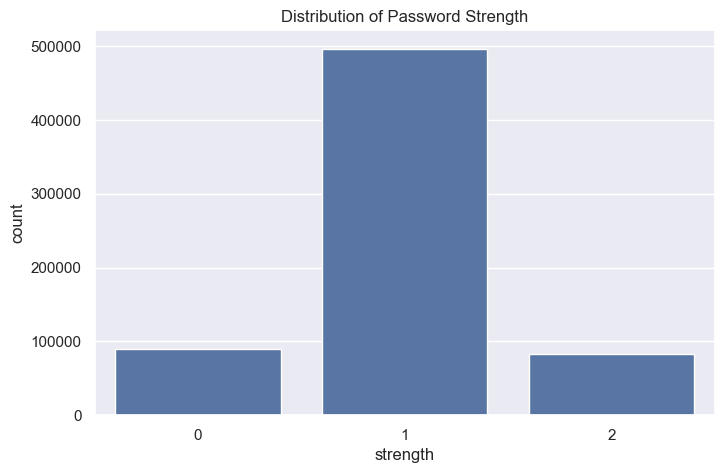

In [61]:
plt.figure(figsize=(8,5))
sns.countplot(x='strength', data=df)
plt.title("Distribution of Password Strength")
plt.show()



The distribution of password strength is centered heavily on level 1, indicating that the vast majority of passwords in the dataset meet basic medium-strength criteria. The relatively low count of level 2 passwords suggests that truly "strong" passwords are less common, which is a key factor to consider when training a classifier to recognize high-security patterns.

### Distribution of passwordlength


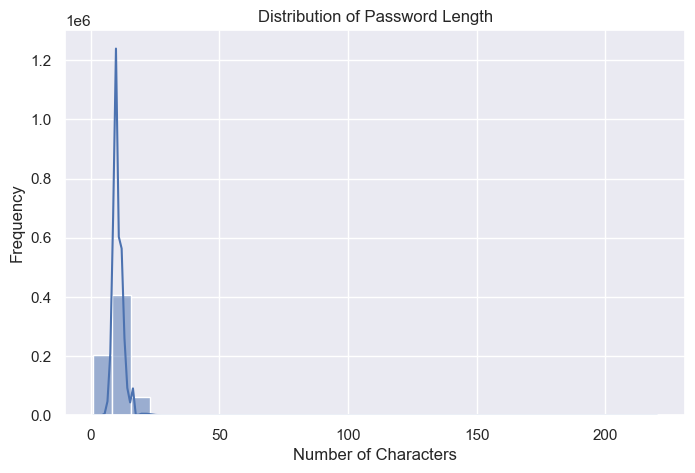

In [62]:
# Create a new column for password length
df['password_length'] = df['password'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['password_length'], bins=30, kde=True)
plt.title("Distribution of Password Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

Shows the spread of password lengths

Right-skewed = Most passwords are short (8-12 characters), while very few are extremely long

The distribution of password length is right-skewed, indicating that the majority of users choose passwords within a specific, shorter range of characters. This skewness is common in authentication data and is a critical feature, as length is often the primary factor determining the "strength" label in your dataset.

## Bivariate Analysis

### Password Length by Strength

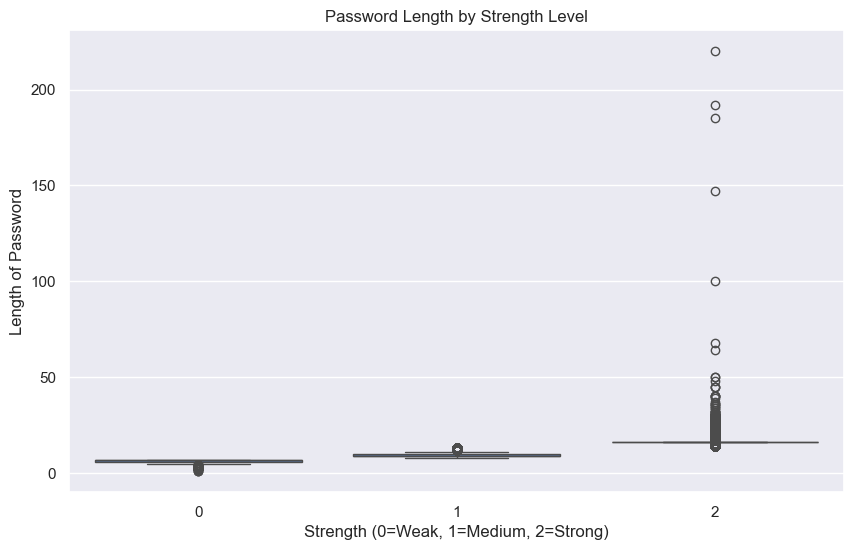

In [63]:
# Create a length column first
df['length'] = df['password'].astype(str).apply(len)

# Bivariate Analysis: Strength vs Length
plt.figure(figsize=(10,6))
sns.boxplot(x='strength', y='length', data=df)
plt.title("Password Length by Strength Level")
plt.ylabel("Length of Password")
plt.xlabel("Strength (0=Weak, 1=Medium, 2=Strong)")
plt.show()

The boxplot illustrates a clear relationship between the length of a password and its assigned strength. Stronger passwords (Level 2) typically have a higher median length compared to weak passwords (Level 0).

### Average Password Length by Strength

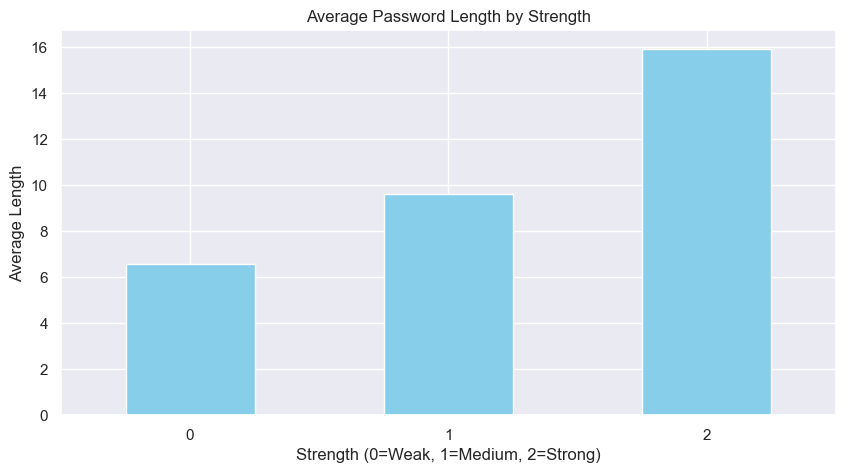

strength
0     6.549604
1     9.618964
2    15.932497
Name: length, dtype: float64


In [64]:
# Grouping by strength and calculating the average length
avg_length_by_strength = df.groupby('strength')['length'].mean()

# Plotting the bar graph
plt.figure(figsize=(10,5))
avg_length_by_strength.plot(kind='bar', color='skyblue')
plt.title("Average Password Length by Strength")
plt.xlabel("Strength (0=Weak, 1=Medium, 2=Strong)")
plt.ylabel("Average Length")
plt.xticks(rotation=0)
plt.show()

# Display the values
print(avg_length_by_strength)

### Top 10 Longest Passwords

In [65]:
# Sorting the dataset by password length to see the top 10 longest passwords
top_10_longest = df[['password', 'length', 'strength']].sort_values(by='length', ascending=False).head(10)

# Display the result
top_10_longest

,password,length,strength
26964,In0LnUoff8wfayJGqzelyDqg4AMl9gBhgl3T2iZeONzh5g...,220,2
331571,qsdfjkhdfsgloijhdfgqhgkqsdiuqsnfbjdjusfsdfq@@f...,192,2
465036,OPy9W1DF4BKWKGJqcU1Ru6cRn1ekM9BvJAP7GxSAw78iaF...,185,2
237921,n43sSh567hDjJ678Fj5D857I6j58SjJ876F89762k3liyU...,147,2
125595,bV1*tB2$s$LW0$fgCqGetE$dZop9ugK7ftSl8BQu*$E4!r...,100,2
295077,adshjfkljdsakg;lkdfsaj;glkjdsaf;ldsakjf8923894...,68,2
8894,2N8ziL2L3N!&R@s6VDTSWP33KyKlvoeCNqT1*3Ejf7rG6l...,64,2
335826,wilver45velostheultimate.Molina.Montero.@.4221...,50,2
324264,LtCdNsG2xnykVqZhdzNoMXNZZjk3oe&CQZryxsfkjybTqr...,50,2
304438,vB83QK4g6DCtyNmVMkJdehj9UGZFfLHAPETsbrRcX2oa72Wp,48,2


The contribution of length to password strength is evident in this top 10 list. Almost all of the longest entries are classified as level 2, confirming that the dataset uses character count as a primary metric for security

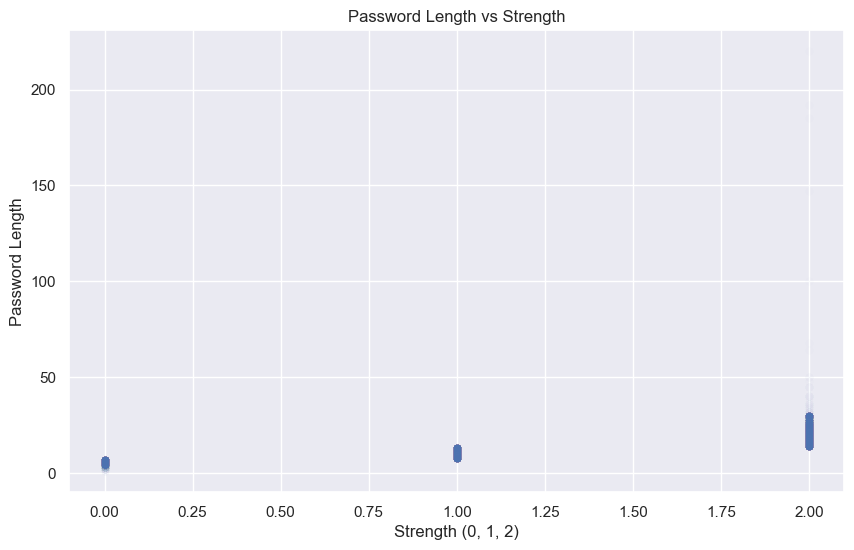

In [71]:
# Scatter plot for your dataset
plt.figure(figsize=(10,6))
sns.scatterplot(x='strength', y='length', data=df, alpha=0.01)
plt.title("Password Length vs Strength")
plt.xlabel("Strength (0, 1, 2)")
plt.ylabel("Password Length")
plt.show()


The scatter plot shows how password lengths are distributed across the three strength levels. Because there are over 600,000 rows, the transparency helps reveal where the data is most dense, confirming that higher strength levels correlate with higher character counts

### Correlation Matrix

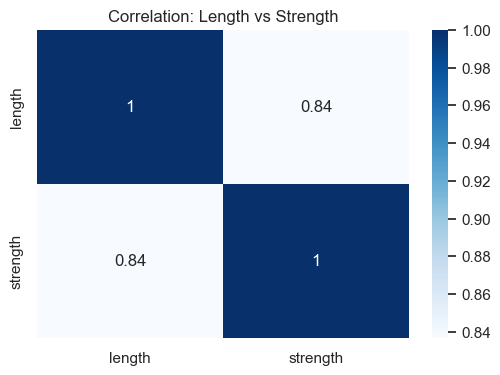

In [72]:
# Calculating correlation between length and strength
correlation_matrix = df[['length', 'strength']].corr()

# Plotting the Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues')
plt.title("Correlation: Length vs Strength")
plt.show()

The heatmap provides a numerical representation of how closely password length and strength are related. A strong positive correlation indicates that as the length of a password increases, the strength classification generally moves from level 0 to level 2. This helps justify using length as a key feature for the predictive model.

## Time-Based Analysis
### Monthly Revenue Trend

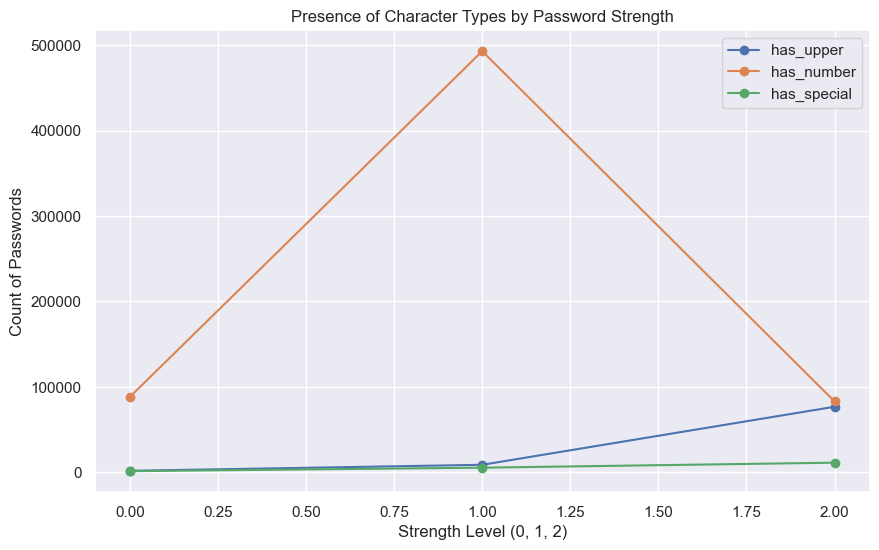

In [73]:
import string

# Function to check for character types
def check_char_types(pswd):
    pswd = str(pswd)
    has_upper = any(char.isupper() for char in pswd)
    has_number = any(char.isdigit() for char in pswd)
    has_special = any(char in string.punctuation for char in pswd)
    return has_upper, has_number, has_special

# Applying the function
df['has_upper'], df['has_number'], df['has_special'] = zip(*df['password'].apply(check_char_types))

# Visualizing the presence of different character types by strength
char_counts = df.groupby('strength')[['has_upper', 'has_number', 'has_special']].sum()
char_counts.plot(kind='line', marker='o', figsize=(10,6))

plt.title("Presence of Character Types by Password Strength")
plt.xlabel("Strength Level (0, 1, 2)")
plt.ylabel("Count of Passwords")
plt.grid(True)
plt.show()

The line plot illustrates how specific password features—such as uppercase letters, numbers, and special characters—contribute to the overall strength classification. While Level 0 and Level 1 passwords rely on simpler structures, Level 2 passwords show a significant spike in the use of diverse character types.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.